# Scalar Perturbations

Compare perturbation evolution for $k$-modes across $\Lambda$CDM, VFDM ($\gamma_k=0$), and VFDM ($\gamma_k=\pi/2$).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d
import copy

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
#%matplotlib widget

# Planck 2018
h_planck = 0.6688
omega_cdm = 0.1206
omega_b = 0.02212
tau_reio = 0.05522
As = 2.092e-9
ns = 0.962

# VFDM
mass = 1.e-25            # eV
mass_Mpc = mass * 1.56e29  # 1/Mpc
frac = 1 - 1.e-6
k_out = [0.001, 1]      # Mpc^-1

colors = ['tab:orange', 'tab:blue', 'tab:olive']

## Run CLASS

In [2]:
precision_settings = {
    'tol_thermo_integration': 1.0e-5,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

common_settings = {
    'h': h_planck, 'omega_b': omega_b, 'A_s': As, 'n_s': ns,
    'tau_reio': tau_reio, 'YHe': 'BBN', 'gauge': 'synchronous',
    'format': 'camb', 'ic': 'ad', 'Omega_fld': 0.,
    'recombination': 'RECFAST',
    'k_output_values': str(k_out).strip('[]'),
}
common_settings.update(precision_settings)

vfdm_settings = {
    'Omega_cdm': omega_cdm * (1 - frac) / h_planck**2,
    'Omega_vf': frac * omega_cdm / h_planck**2,
    'attractor_ic_vf': 'yes',
    'vf_parameters': '%s, 1.e-16, 1.e-30, 0.01' % mass,
    'vf_tuning_index': 3, 'output': 'tCl',
    'vector_background_mode': 'bianchi'
}


def run_class(extra):
    M = Class()
    M.set({**common_settings, **extra})
    M.compute()
    perts = copy.deepcopy(M.get_perturbations())
    bg = copy.deepcopy(M.get_background())
    M.struct_cleanup()   # <-- add this
    M.empty()
    return perts, bg     # return M? you don't use it much later except for M_0.h()


perts_lcdm, bg_lcdm = run_class({'Omega_cdm': omega_cdm / h_planck**2, 'Omega_vf': 0., 'output': 'tCl mPk'})
perts_0, _ = run_class({**vfdm_settings, 'svt_coupling': 'no', 'gamma_Ak': 0.})
perts_pi2, bg = run_class({**vfdm_settings, 'svt_coupling': 'no', 'gamma_Ak': np.pi / 2.})

Background quantities and Jeans scale:

In [3]:
bg_a = 1 / (1 + bg['z'])
bg_H = bg['H [1/Mpc]']

# Oscillation onset: H(a_osc) = m
a_osc = interp1d(bg_H / mass_Mpc, bg_a)(1.)
H_osc = interp1d(bg_H / mass_Mpc, bg_H)(1.)
kj = a_osc * np.sqrt(mass_Mpc * H_osc) / h_planck

print('mass = %s' % mass)
print(r'k_j =  %s h/Mpc' % kj)
print(r'k_j =  %s 1/Mpc' % str(kj * h_planck))

mass = 1e-25
k_j =  0.27638647321272286 h/Mpc
k_j =  0.18484727328466904 1/Mpc


## Plotting Utilities

In [4]:
def plot_std_comparison(key, ylabel, key_lcdm=None, skip_early=0,
                        show_horizon=True, show_osc=True):

    if key_lcdm is None:
        key_lcdm = key

    model_rows = [
        (perts_0,    'solid',  key,      r'$\gamma=0$',     False),
        (perts_pi2,  'dashed', key,      r'$\gamma=\pi/2$', False),
        (perts_lcdm, 'dashed', key_lcdm, r'$\Lambda$CDM',    True),
    ]

    plt.figure(figsize=(8, 6))
    for i, k in enumerate(k_out):
        for perts, ls, pkey, mlabel, is_lcdm in model_rows:
            p = perts['scalar'][i]
            s = skip_early
            color = 'k' if is_lcdm else colors[i]
            label = None if (is_lcdm and i > 0) else rf'$k={k}$ Mpc$^{{-1}}$ ({mlabel})'
            try:
                y = np.abs(p[pkey][s:])
                if not np.any(y > 0):
                    continue  # skip fields that are identically zero
                plt.loglog(p['a'][s:], y, color=color, lw=3, ls=ls, label=label)
            except KeyError:
                continue  # key missing for this model (e.g. theta_cdm)

        if show_horizon:
            try:
                k_over_aH = interp1d(k/(bg_H*bg_a), bg_a)(1.)
                plt.axvline(k_over_aH, color=colors[i], ls='dashed', lw=1.5, alpha=0.6)
            except ValueError:
                pass

    if show_osc:
        plt.axvline(a_osc, color='k', ls='dashdot', lw=2, label=r'$a_{\rm osc}$')

    plt.xlabel(r'$a$', size=18)
    plt.ylabel(ylabel, size=18)
    plt.title(rf'$m = {mass}\,\rm{{eV}}$', fontsize=16)
    plt.legend(fontsize=12)
    plt.xlim(perts_pi2['scalar'][0]['a'][0], 1)
    plt.tick_params(labelsize=14)
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

## $\alpha$

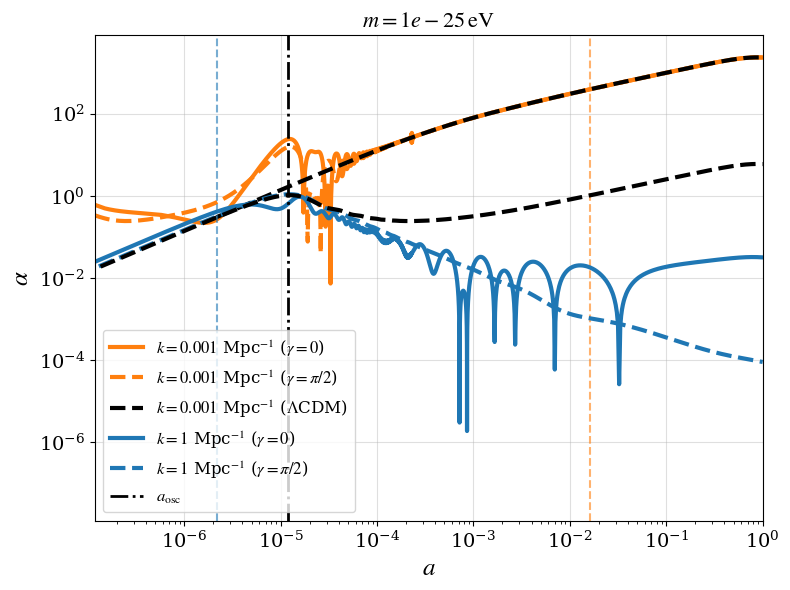

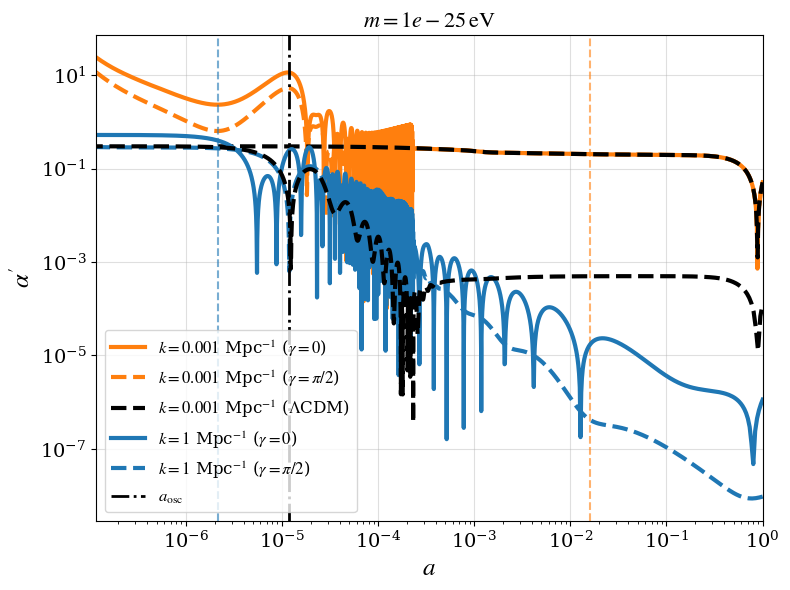

In [5]:
plot_std_comparison('alpha', r'$\alpha$')
plot_std_comparison('alpha_prime', r"$\alpha'$")

## Metric perturbation: $\eta$

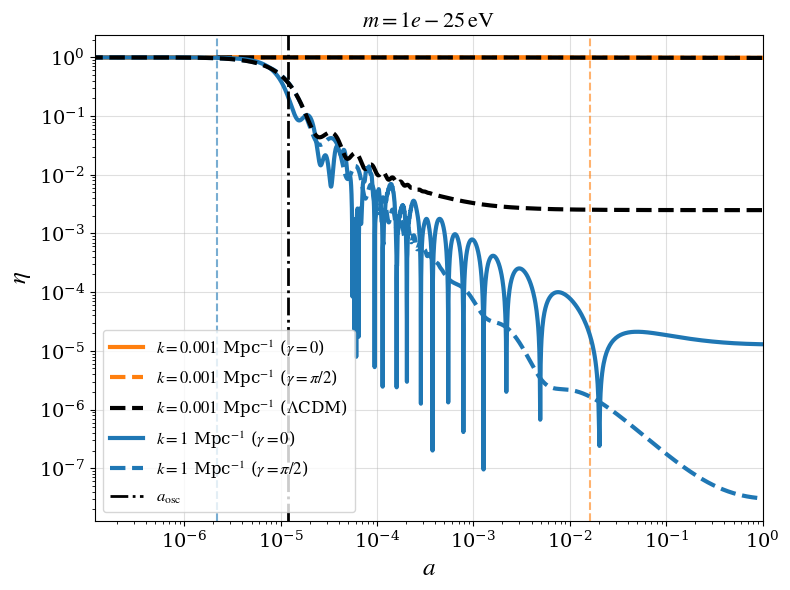

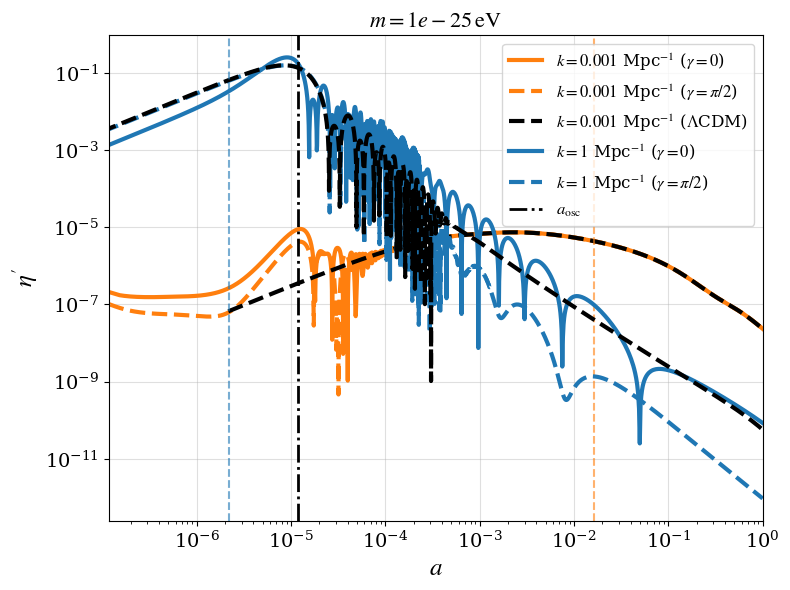

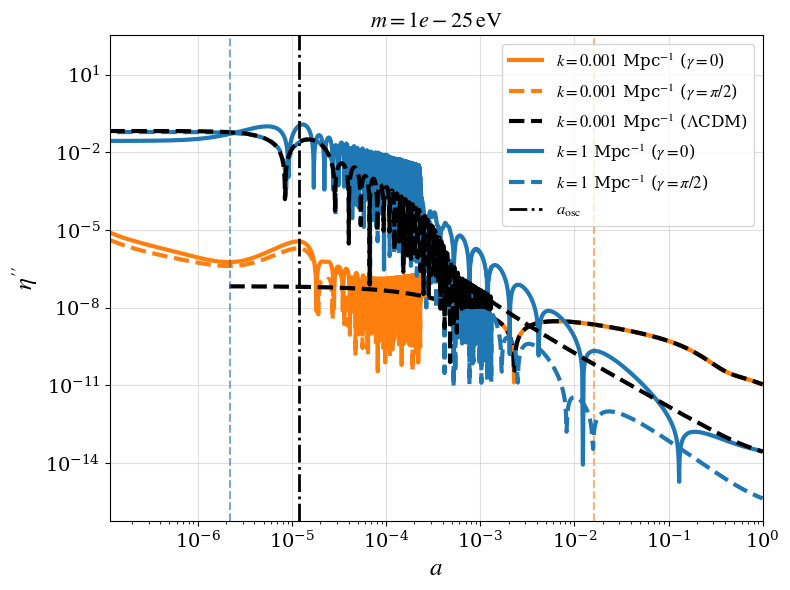

In [6]:
plot_std_comparison('eta', r'$\eta$', key_lcdm='eta')
plot_std_comparison('eta_prime', r'$\eta^{\prime}$', key_lcdm='eta_prime')
plot_std_comparison('eta_prime_prime', r'$\eta^{\prime\prime}$', key_lcdm='eta_prime_prime')

## Metric perturbation: $h$

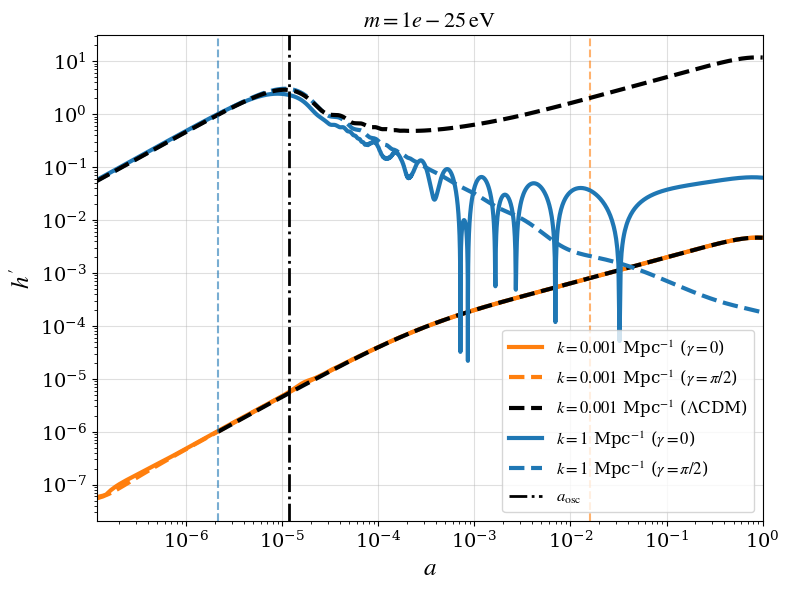

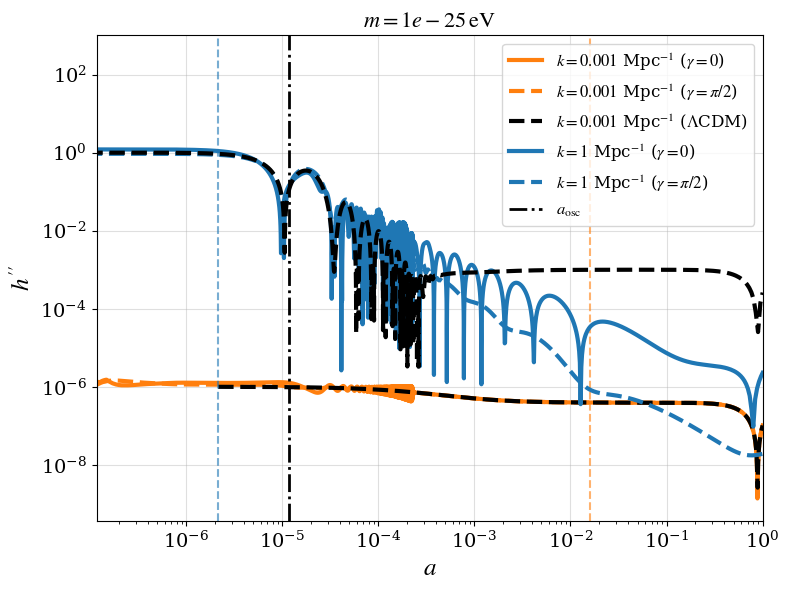

In [7]:
plot_std_comparison('h_prime', r'$h^{\prime}$', key_lcdm='h_prime')
plot_std_comparison('h_prime_prime', r'$h^{\prime\prime}$', key_lcdm='h_prime_prime')

## $\delta_A$

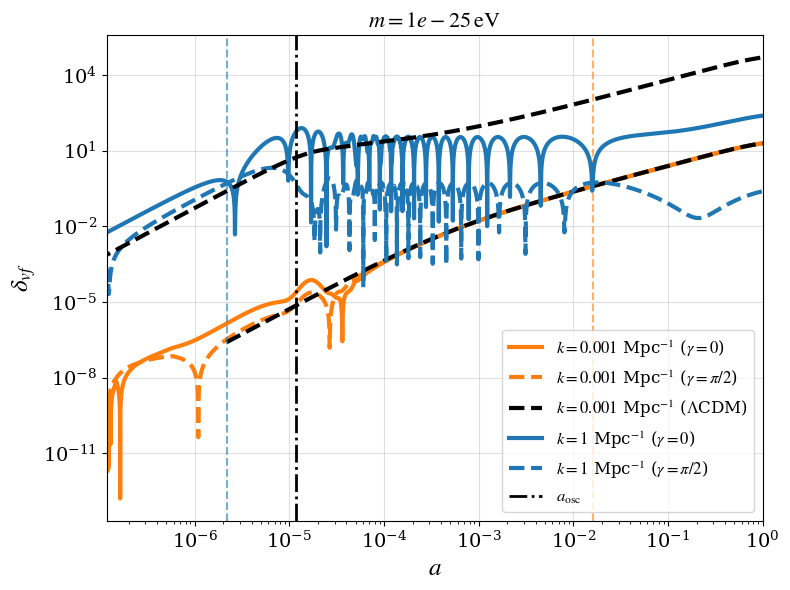

In [8]:
plot_std_comparison('delta_vf', r'$\delta_{vf}$', key_lcdm='delta_cdm')

## $\theta_A$

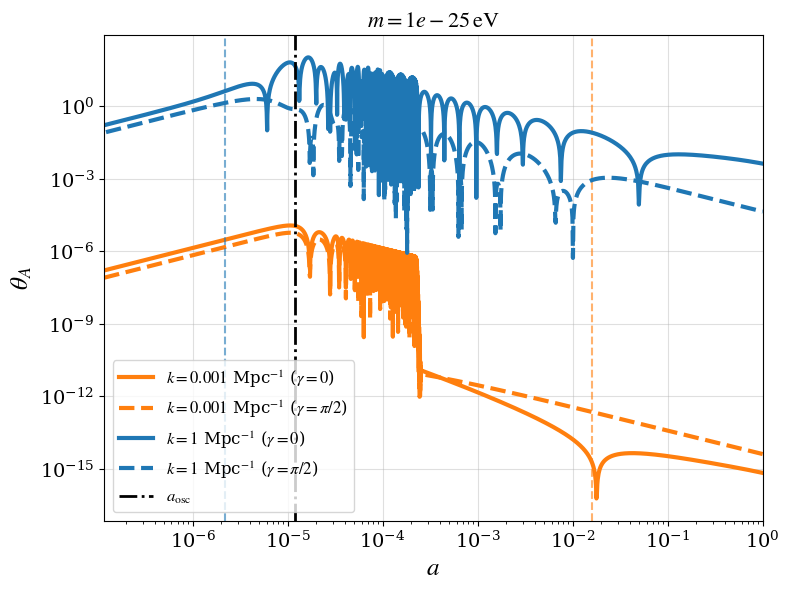

In [9]:
plot_std_comparison('theta_vf', r'$\theta_A$')

## $\Sigma_A$

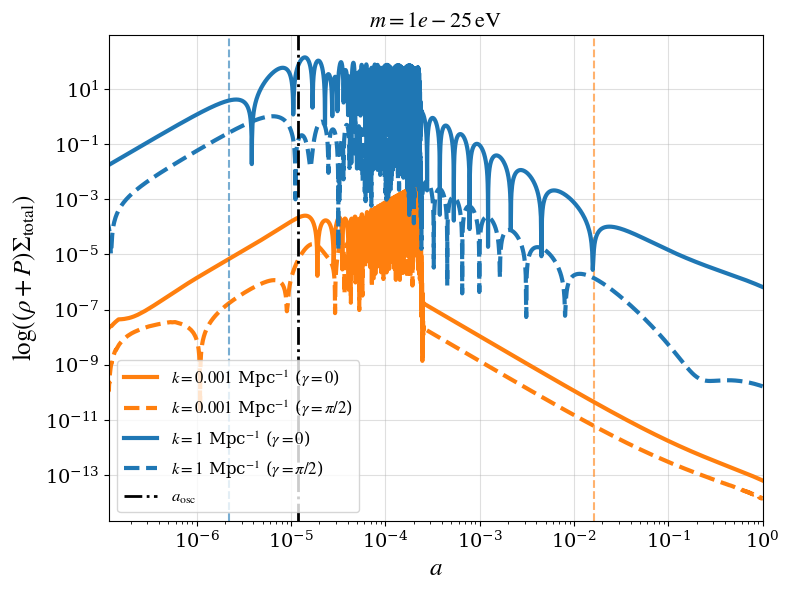

In [10]:
plot_std_comparison('shear_vf', r'$\log((\rho+P)\Sigma_{\rm total})$')

## Weinberg adiabatic mode

Mode never enters the horizon, so the adiabatic mode is a good approximation:


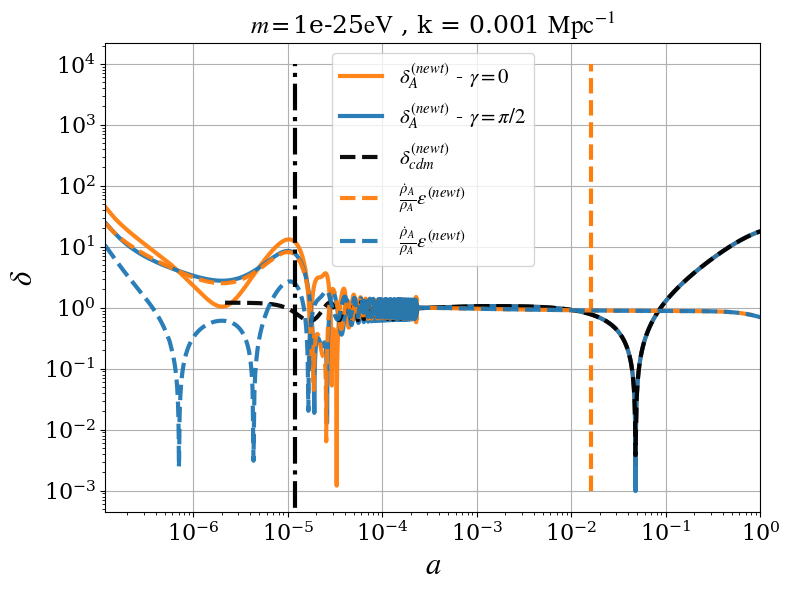

Once the mode enters the horizon, the adiabatic mode is no longer a good approximation:


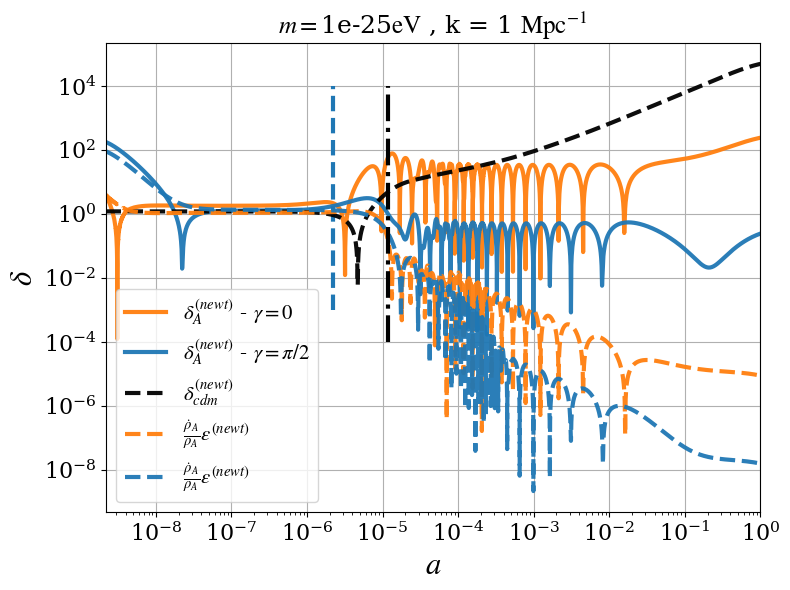

In [11]:
def compare_adiabatic(k_index=0):
    plt.figure(figsize=(8, 6))
    i = k_index
    k = k_out[i]
    one_kpi2 = perts_pi2['scalar'][i]
    one_k0 = perts_0['scalar'][i]
    one_klcdm = perts_lcdm['scalar'][i]
    api2 = one_kpi2['a']
    a0 = one_k0['a']
    alcdm = one_klcdm['a']
    phi0 = one_k0['phi']
    phipi2 = one_kpi2['phi']
    alphapi2 = one_kpi2['alpha']
    delta_vfpi2 = one_kpi2['delta_vf']
    alpha0 = one_k0['alpha']
    delta_vf0 = one_k0['delta_vf']
    delta_vflcdm = one_klcdm['delta_cdm']
    alphalcdm = one_klcdm['alpha']

    background_k_over_aH = k/(bg['H [1/Mpc]']*bg_a)
    try:
        k_over_aH = interp1d(background_k_over_aH, bg_a)(1.)
        plt.vlines(x=k_over_aH, ymin=0.001, ymax=1.e4, colors=colors[i], linestyles='dashed', lw=3)
    except ValueError:
        pass

    rho_A = interp1d(bg_a, bg['(.)rho_vf'])
    H_cosmic = interp1d(bg_a, bg['H [1/Mpc]'])
    rho_A_prime = interp1d(bg_a, -3.*bg_a*bg['H [1/Mpc]']*(bg['(.)rho_vf']+bg['(.)p_vf']))

    delta_vfpi2_newton = delta_vfpi2 - rho_A_prime(api2)/rho_A(api2) * alphapi2
    delta_vf0_newton = delta_vf0 - rho_A_prime(a0)/rho_A(a0) * alpha0
    delta_cdm_newton = delta_vflcdm - rho_A_prime(alcdm)/rho_A(alcdm) * alphalcdm

    epsilon0 = - phi0/(2. * a0*H_cosmic(a0))
    epsilonpi2 = - phipi2/(2. * api2*H_cosmic(api2))

    plt.xlabel(r'$a$', size=22)
    plt.ylabel(r'$\delta$', size=22)
    plt.loglog(a0, np.abs(delta_vf0_newton), colors[0], linestyle='solid', label=r'$\delta_A^{(newt)}$ - $\gamma = 0$', lw=3, alpha=0.95)
    plt.loglog(api2, np.abs(delta_vfpi2_newton), colors[1], linestyle='solid', label=r'$\delta_A^{(newt)}$ - $\gamma = \pi/2$', lw=3, alpha=0.95)
    plt.loglog(alcdm, np.abs(delta_cdm_newton), 'k--', label=r'$\delta_{cdm}^{(newt)}$', lw=3, alpha=0.95)
    plt.loglog(a0, np.abs(rho_A_prime(a0)/rho_A(a0) * epsilon0), colors[0], linestyle='dashed', label=r'$\frac{\dot{\rho}_A}{\rho_A}\epsilon^{(newt)}$', lw=3, alpha=0.95)
    plt.loglog(api2, np.abs(rho_A_prime(api2)/rho_A(api2) * epsilonpi2), colors[1], linestyle='dashed', label=r'$\frac{\dot{\rho}_A}{\rho_A}\epsilon^{(newt)}$', lw=3, alpha=0.95)
    plt.vlines(x=a_osc, ymin=0.0001, ymax=1.e4, color='k', linestyle='dashdot', lw=3)
    plt.legend(fontsize=15)
    plt.xlim(api2[0], 1)
    plt.tick_params(labelsize=16)
    plt.grid()
    plt.title(r'$m = $'+str(mass)+r'$\rm{eV}$'+' , '+'k'+' = '+str(np.round(k, 4))+r' $\rm{Mpc}^{-1}$', fontsize=18)
    plt.tight_layout()
    plt.show()

print('Mode never enters the horizon, so the adiabatic mode is a good approximation:')
compare_adiabatic(k_index=0)
print('Once the mode enters the horizon, the adiabatic mode is no longer a good approximation:')
compare_adiabatic(k_index=1)